# 🕵️‍♂️ Causal Inference 101: 为什么 A/B Test 不够用？

> **Scenario**: 你是某零售巨头的 Senior DA。公司要在部分门店进行 **"装修升级 (Renovation)"** 实验。
> - **Treatment Group**: 选择了 50 家 **业绩本来就很好** 的门店进行装修 (Selection Bias)。
> - **Control Group**: 剩下的 50 家普通门店。
> - **Goal**: 装修到底带来了多少**增量 (Lift)**？

## 核心问题
1. 直接比 `Post` (装修后) 的业绩？ -> **不公平**，因为装修店本来就好。
2. 直接比 `Pre vs Post` (装修前后)？ -> **不公平**，因为可能正好赶上圣诞节 (Trend)，大家都涨了。
3. **Solution**: **DID (Difference-in-Differences)** 双重差分。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 模拟数据 (God Mode: 我们知道真实增量是 +10%)
np.random.seed(42)
n_stores = 100
n_days = 200
treatment_start = 100

# 构造时间轴
dates = pd.date_range(start='2025-01-01', periods=n_days)
df_list = []

# 构造门店
for store_id in range(n_stores):
    # group=1 (Treatment, 装修店), group=0 (Control)
    # ⚠️ Selection Bias: 我们居然选了本来就好的店做实验！(Baseline 高)
    is_treatment = 1 if store_id < 50 else 0
    baseline_sales = 1000 if is_treatment else 800  
    
    for day_cnt, date in enumerate(dates):
        # 1. 自然趋势 (Trend): 大家都越来越好 (e.g. 经济复苏)
        trend = day_cnt * 0.5 
        
        # 2. 真实增量 (Treatment Effect): 只有装修店在 Day 100 之后才有 +100 的提升
        effect = 100 if (is_treatment and day_cnt >= treatment_start) else 0
        
        # 3. 噪音 (Noise)
        noise = np.random.normal(0, 50)
        
        sales = baseline_sales + trend + effect + noise
        
        df_list.append({
            'date': date,
            'store_id': store_id,
            'group': 'Treatment' if is_treatment else 'Control',
            'is_treatment': is_treatment,
            'is_post': 1 if day_cnt >= treatment_start else 0,
            'sales': sales
        })

df = pd.DataFrame(df_list)
print("✅ Data Simulated: Selection Bias (Baseline Diff) + Time Trend Included.")

✅ Data Simulated: Selection Bias (Baseline Diff) + Time Trend Included.


## ❌ 错误做法 1: Cross-Sectional Comparison (横向对比)
> "装修后的门店，平均销量比没装修的高多少？"

In [2]:
# 只看 Post 阶段
df_post = df[df['is_post'] == 1]
avg_sales = df_post.groupby('group')['sales'].mean()
diff = avg_sales['Treatment'] - avg_sales['Control']

print(f"Naive 1 (Post only): Treatment - Control = {diff:.2f}")
print(f"❌ 错误原因: 包含了 {1000-800} 的 Baseline 差异 (Selection Bias)！")

Naive 1 (Post only): Treatment - Control = 300.88
❌ 错误原因: 包含了 200 的 Baseline 差异 (Selection Bias)！


## ❌ 错误做法 2: Pre-Post Comparison (纵向对比)
> "装修后的门店，比装修前涨了多少？"

In [3]:
# 只看 Treatment 组
df_treat = df[df['group'] == 'Treatment']
before = df_treat[df_treat['is_post'] == 0]['sales'].mean()
after = df_treat[df_treat['is_post'] == 1]['sales'].mean()
diff = after - before

print(f"Naive 2 (Pre-Post): After - Before = {diff:.2f}")
print(f"❌ 错误原因: 包含了 {(200-0)/2 * 0.5} 的自然增长 (Time Trend)！")

Naive 2 (Pre-Post): After - Before = 151.08
❌ 错误原因: 包含了 50.0 的自然增长 (Time Trend)！


## ✅ 正确做法: DID (Difference in Differences)
> 公式: `(Treatment_Post - Treatment_Pre) - (Control_Post - Control_Pre)`
> 
> 逻辑: **(装修后的涨幅) - (没装修的自然涨幅) = 纯装修带来的增量**

In [5]:
# 1. 计算四象限均值
stats = df.groupby(['group', 'is_post'])['sales'].mean().unstack()
print("📊 Group Stats:\n")
display(stats)

# 2. Calculate DID
treat_diff = stats.loc['Treatment', 1] - stats.loc['Treatment', 0]
control_diff = stats.loc['Control', 1] - stats.loc['Control', 0]
did_effect = treat_diff - control_diff

print("-" * 30)
print(f"Treatment Group Lift: {treat_diff:.2f} (含 Trend + Effect)")
print(f"Control Group Lift  : {control_diff:.2f} (纯 Trend)")
print(f"✅ DID Effect        : {did_effect:.2f} (Close to True Effect 100!)")

📊 Group Stats:



is_post,0,1
group,,
Control,826.544195,874.309210
Treatment,1024.102191,1175.184211


------------------------------
Treatment Group Lift: 151.08 (含 Trend + Effect)
Control Group Lift  : 47.77 (纯 Trend)
✅ DID Effect        : 103.32 (Close to True Effect 100!)


## 📈 可视化: 平行趋势检验 (Parallel Trend Check)
> DID 成立的前提：**如果没有装修，Experiment 组的趋势应该和 Control 组平行。**

/var/folders/35/q6rh83x91bzgf3gcsb_13f_80000gn/T/ipykernel_77940/2656608610.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='date', y='sales', hue='group', ci=None)


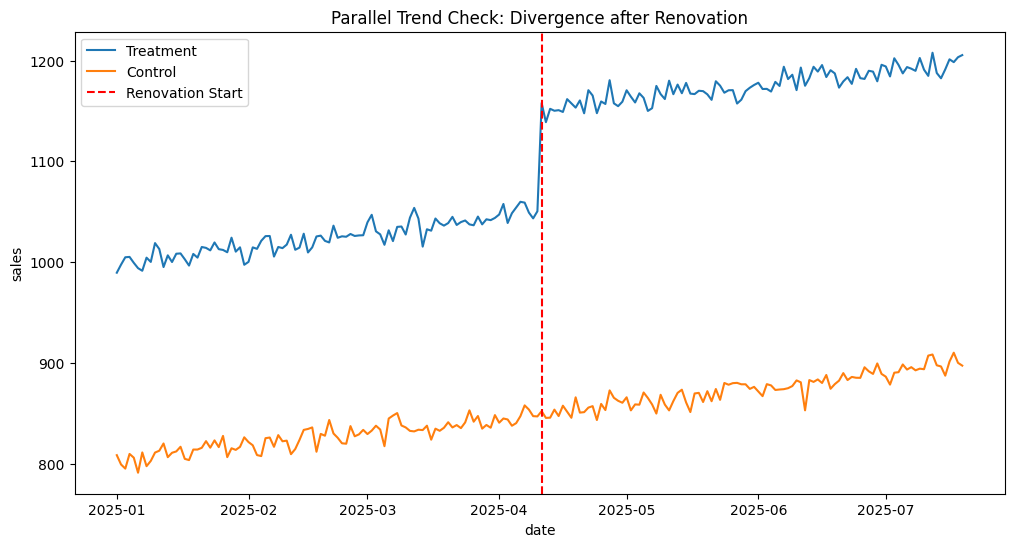

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='sales', hue='group', ci=None)
plt.axvline(x=dates[treatment_start], color='red', linestyle='--', label='Renovation Start')
plt.title('Parallel Trend Check: Divergence after Renovation')
plt.legend()
plt.show()